In [16]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from pyproj import Transformer
from hostrada4py import hostradaArea as ha

HOSTRADA_VAR = "tas" # outside air temperature
#HOSTRADA_VAR = "sfcWind" # wind speed
#HOSTRADA_VAR = "uhi" # Urban Heat Island Intensity
#HOSTRADA_VAR = "rsds" # global radiation
#HOSTRADA_VAR = "clt" # cloud cover
#HOSTRADA_VAR = "hurs" # relative humidity
#HOSTRADA_VAR = "tdew" # dew point temperature

## Definition of the area, the time period and download of the HOSTRADA values

In [17]:
# A polygon which includes the area of the city of Berlin
polygon_points = [
    (13.0884, 52.3383),
    (13.7612, 52.3383),
    (13.7612, 52.6755),
    (13.0884, 52.6755),
]

start_utc = "2019-08-01T00:00:00"
end_utc = "2019-08-08T23:00:00"

gdf = ha.extract_values_for_polygon(
    var= HOSTRADA_VAR,
    polygon_lonlat=polygon_points,
    start_utc=start_utc,
    end_utc=end_utc,
    selection_mode="within",
    return_geodataframe=True)
print(f"Number of data records: {len(gdf)}")

gdf.to_file("HOSTRADA_poly_" + HOSTRADA_VAR + ".geojson", driver="GeoJSON")
gdf.drop(columns="geometry").to_csv("HOSTRADA_poly_" + HOSTRADA_VAR + ".csv", index=False)
summary = ha.summarize_values_period(gdf, var = HOSTRADA_VAR)
summary.to_csv("HOSTRADA_poly_summary_" + HOSTRADA_VAR + ".csv", index=False)

print("\nErgebnisse geschrieben:")
print(" - HOSTRADA_poly_" + HOSTRADA_VAR + ".geojson")
print(" - HOSTRADA_poly_" + HOSTRADA_VAR + ".csv")
print(" - HOSTRADA_poly_summary_" + HOSTRADA_VAR + ".csv")

Lade Datei: https://opendata.dwd.de/climate_environment/CDC/grids_germany/hourly/hostrada/air_temperature_mean/tas_1hr_HOSTRADA-v1-0_BE_gn_2019080100-2019083123.nc
Lese Datei: hostrada_cache/tas_1hr_HOSTRADA-v1-0_BE_gn_2019080100-2019083123.nc
Number of data records: 290880

Ergebnisse geschrieben:
 - location_HOSTRADA_poly_tas.geojson
 - location_HOSTRADA_poly_tas.csv
 - location_HOSTRADA_poly_summary_tas.csv


## Spatial distribution of the HOSTRADA variable for one selected time point

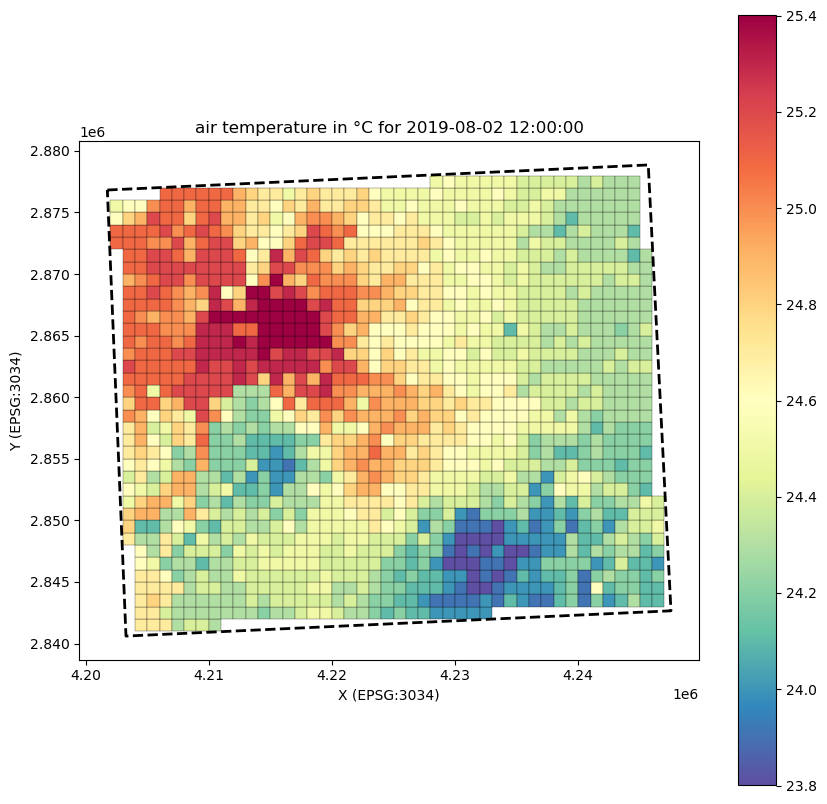

In [18]:
# selcted time point
timestamp = pd.Timestamp("2019-08-02T12:00:00")
gdf["time"] = pd.to_datetime(gdf["time"])
gdf_one = gdf[gdf["time"] == timestamp].copy()

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3034", always_xy=True)
polygon_3034 = Polygon([transformer.transform(lon, lat) for lon, lat in polygon_points])

polygon_gdf = gpd.GeoDataFrame(
    {"name": ["Abfragepolygon"]},
    geometry=[polygon_3034],
    crs="EPSG:3034")

fig, ax = plt.subplots(figsize=(10, 10))

gdf_one.plot(
    column=HOSTRADA_VAR,
    ax=ax,
    #cmap="RdBu_r",
    cmap="Spectral_r",
    legend=True,
    #vmin=0,
    #vmax=5,
    edgecolor="black",
    linewidth=0.2,
)

polygon_gdf.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2,
    linestyle="--"
)

if HOSTRADA_VAR == "tas":
    title = "air temperature in °C"
elif HOSTRADA_VAR == "uhi":
    title = "Urban Heat Island Intensity in °C"
elif HOSTRADA_VAR == "sfcWind":
    title = "wind speed in m/s"
elif HOSTRADA_VAR == "rsds":
    title = "Global radiation in W/m2"
elif HOSTRADA_VAR == "clt":
    title = "cöoud cover in eighth"
elif HOSTRADA_VAR == "hurs":
    title = "relative humidity in percent"
elif HOSTRADA_VAR == "tdew":
    title = "dew point temperature in °C"
else:
    title = "unknown"

ax.set_title(title + " for " + str(timestamp))
ax.set_xlabel("X (EPSG:3034)")
ax.set_ylabel("Y (EPSG:3034)")
ax.set_aspect("equal")
plt.show()


## Hourly time series of area mean values of the whole polygon.

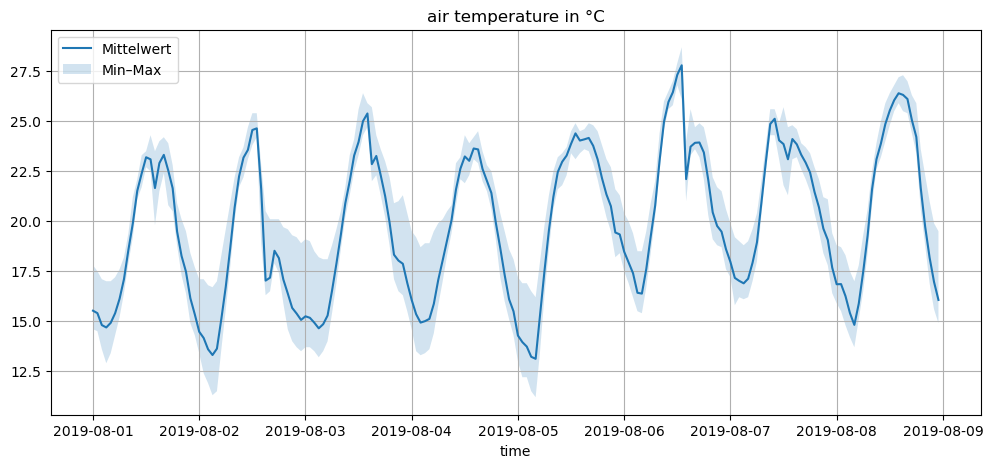

In [19]:
if HOSTRADA_VAR == "tas":
    title = "air temperature in °C"
elif HOSTRADA_VAR == "uhi":
    title = "Urban Heat Island Intensity in °C"
elif HOSTRADA_VAR == "sfcWind":
    title = "wind speed in m/s"
elif HOSTRADA_VAR == "rsds":
    title = "Global radiation in W/m2"
elif HOSTRADA_VAR == "clt":
    title = "cloud cover in eighth"
elif HOSTRADA_VAR == "hurs":
    title = "relative humidity in percent"
elif HOSTRADA_VAR == "tdew":
    title = "dew point temperature in °C"
else:
    title = "unknown"

summary["time"] = pd.to_datetime(summary["time"])

plt.figure(figsize=(12, 5))
plt.plot(summary["time"], summary["value_mean"], label="Mittelwert")
plt.fill_between(summary["time"], summary["value_min"], summary["value_max"], alpha=0.2, label="Min–Max")
plt.xlabel("time")
#plt.ylabel(title)
plt.title(title)
plt.grid(True)
plt.legend()
plt.show()
